In [18]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path("/content/drive/MyDrive/ML-wakacyjne-wyzwanie-2026") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

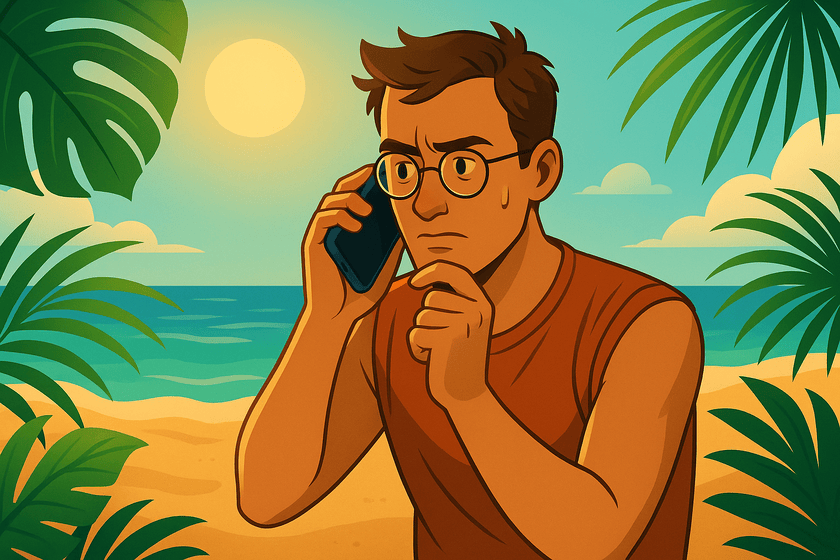

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [20]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [21]:
titanic_df.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


In [22]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

Kolumny które nie przydadzą się w analizie z pliku titanic.csv to: PassengerID (ale zostawiamy bo jest jako ID tabeli), Name, Ticket, Cabin

In [23]:
columns_to_drop = ['Name', 'Ticket', 'Cabin']
titanic_df = titanic_df.drop(columns=columns_to_drop)

In [24]:
titanic_df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S


Sprawdzenie ile jest brakujących wartości w danych kolumnach i uzupełnienie wartości numerycznych medianą, a wartości kategorycznych modą (najczęstszą wartością)

In [25]:
print(titanic_df.isna().sum())

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare         98
Embarked      2
dtype: int64


In [26]:
age_median = titanic_df['Age'].median()
titanic_df['Age'] = titanic_df['Age'].fillna(age_median)
print(titanic_df.isna().sum())

Survived     0
Pclass       0
Sex          0
Age          0
SibSp        0
Parch        0
Fare        98
Embarked     2
dtype: int64


In [27]:
fare_median = titanic_df['Fare'].median()
titanic_df['Fare'] = titanic_df['Fare'].fillna(fare_median)
print(titanic_df.isna().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64


In [28]:
embarked_mode = titanic_df['Embarked'].mode()[0]
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(embarked_mode)
print(titanic_df.isna().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


Dodanie dwóch nowych kolumn do naszej tabeli (rozmiaru całej rodziny i czy jest sam)

In [29]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1
titanic_df['IsAlone'] = titanic_df['FamilySize'].apply(lambda x: 1 if x == 1 else 0)

titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
PassengerId,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,2,0
2,1,1,female,38.0,1,0,71.2833,C,2,0
3,1,3,female,26.0,0,0,7.9250,S,1,1
4,1,1,female,35.0,1,0,53.1000,S,2,0
5,0,3,male,35.0,0,0,8.0500,S,1,1


Zakodowanie danych kategorialnych (Sex i Embarked) jako numeryczne (kodowanie ordynalne)

In [30]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})


mapping = {
    'S': 0,
    'C': 1,
    'Q': 2
}

titanic_df['Embarked'] = titanic_df['Embarked'].map(mapping)

titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
PassengerId,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,0,2,0
2,1,1,1,38.0,1,0,71.2833,1,2,0
3,1,3,1,26.0,0,0,7.9250,0,1,1
4,1,1,1,35.0,1,0,53.1000,0,2,0
5,0,3,0,35.0,0,0,8.0500,0,1,1


Import bibliotek

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

Wizualizacja danych rozkładu wieku i opłaty za bilet oraz outlierów dla tych dwóch kategorii w postaci boxplotów

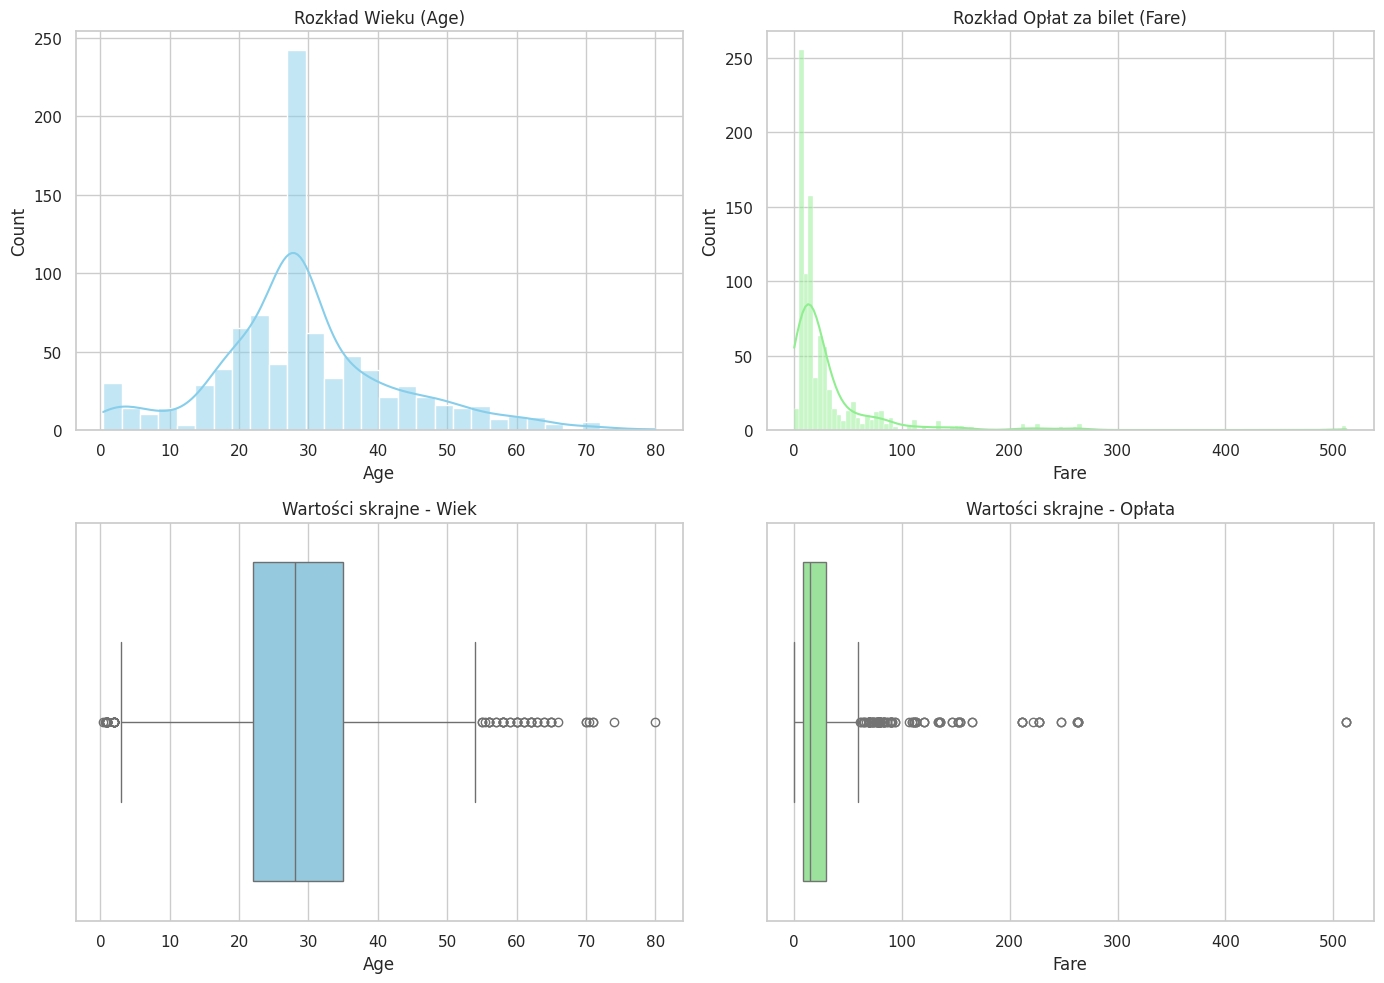

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

sns.histplot(titanic_df['Age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Rozkład Wieku (Age)')

sns.histplot(titanic_df['Fare'], kde=True, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Rozkład Opłat za bilet (Fare)')

sns.boxplot(x=titanic_df['Age'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Wartości skrajne - Wiek')

sns.boxplot(x=titanic_df['Fare'], ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Wartości skrajne - Opłata')

plt.tight_layout()
plt.show()

Sprawdzenie outlierów za pomocą wzoru matematycznego IQR dla kolumn Age i Fare

In [33]:
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = ((df[column] < lower_limit) | (df[column] > upper_limit)).sum()
    percent = (outliers / len(df)) * 100

    print(f"Kolumna '{column}': znaleziono {outliers} outlierów ({percent:.1f}% danych)")

print("--- ANALIZA OUTLIERÓW ---")
check_outliers(titanic_df, 'Age')
check_outliers(titanic_df, 'Fare')

--- ANALIZA OUTLIERÓW ---
Kolumna 'Age': znaleziono 66 outlierów (7.4% danych)
Kolumna 'Fare': znaleziono 110 outlierów (12.3% danych)


Szukanie outlierów kategorialnych (rzadkich wartości)

In [34]:
kolumny_do_sprawdzenia = ['Pclass', 'SibSp', 'Parch', 'FamilySize']

print("Szukanie outlierów kategorialnych (rzadkich wartości)")
for col in kolumny_do_sprawdzenia:
    print(f"\nRozkład dla kolumny '{col}':")
    print(titanic_df[col].value_counts())

Szukanie outlierów kategorialnych (rzadkich wartości)

Rozkład dla kolumny 'Pclass':
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Rozkład dla kolumny 'SibSp':
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Rozkład dla kolumny 'Parch':
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

Rozkład dla kolumny 'FamilySize':
FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64


Wizualizacja wykresów gęstości Wieku i Opłaty w porównaniu z przeżywalnością

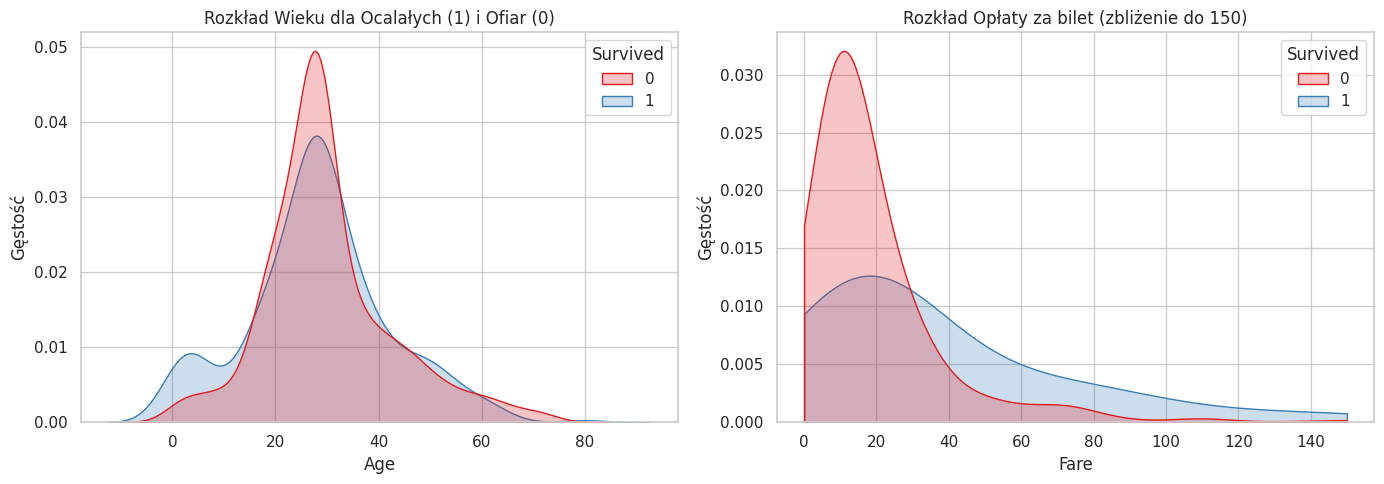

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Wykres gęstości: Wiek vs Przeżycie
sns.kdeplot(data=titanic_df, x='Age', hue='Survived', fill=True, ax=axes[0], palette='Set1', common_norm=False)
axes[0].set_title('Rozkład Wieku dla Ocalałych (1) i Ofiar (0)')
axes[0].set_ylabel('Gęstość')

# Wykres gęstości: Opłata vs Przeżycie
sns.kdeplot(data=titanic_df, x='Fare', hue='Survived', fill=True, ax=axes[1], palette='Set1', common_norm=False, clip=(0, 150))
axes[1].set_title('Rozkład Opłaty za bilet (zbliżenie do 150)')
axes[1].set_ylabel('Gęstość')

plt.tight_layout()
plt.show()

Wykresy słupkowe szans na przeżycie wg kategorii takich jak klasa, płeć, wielkość rodziny czy też samotników

/tmp/ipykernel_804/918961028.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic_df, x='Pclass', y='Survived', ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_804/918961028.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic_df, x='Sex', y='Survived', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_804/918961028.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic_df, x='FamilySize', y='Survived', ax=axes[1, 0], palette='magma')
/tmp/ipykernel_804/918961028.py:20: FutureWarning: 

Passing `palette` with

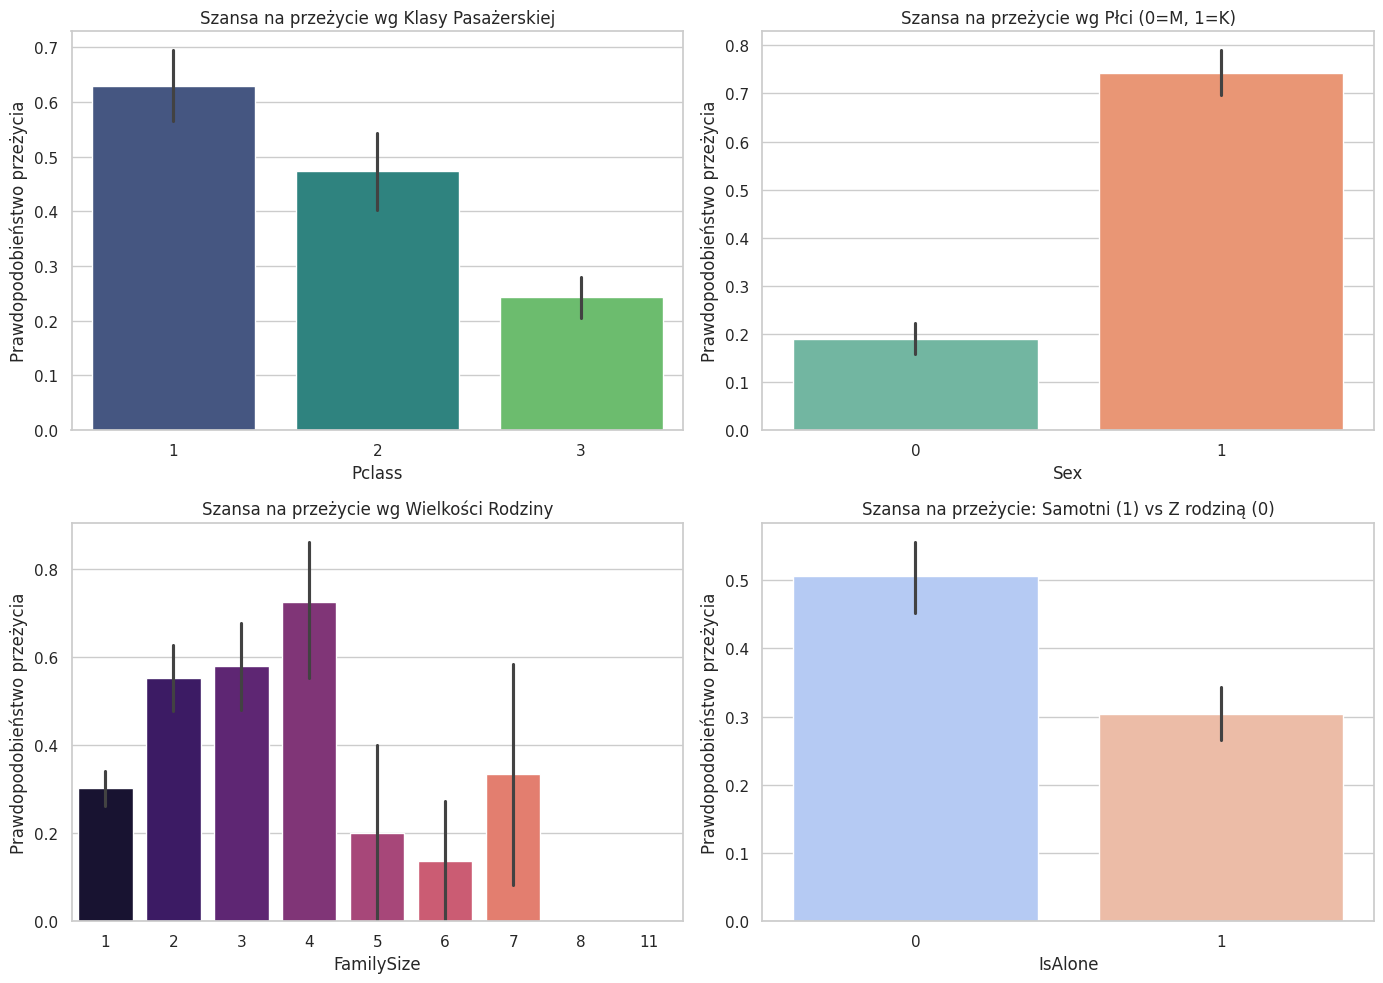

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

# Wykres 1: Klasa vs Przeżycie
sns.barplot(data=titanic_df, x='Pclass', y='Survived', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Szansa na przeżycie wg Klasy Pasażerskiej')
axes[0, 0].set_ylabel('Prawdopodobieństwo przeżycia')

# Wykres 2: Płeć vs Przeżycie (0 = Mężczyzna, 1 = Kobieta)
sns.barplot(data=titanic_df, x='Sex', y='Survived', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Szansa na przeżycie wg Płci (0=M, 1=K)')
axes[0, 1].set_ylabel('Prawdopodobieństwo przeżycia')

# Wykres 3: Wielkość rodziny vs Przeżycie
sns.barplot(data=titanic_df, x='FamilySize', y='Survived', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Szansa na przeżycie wg Wielkości Rodziny')
axes[1, 0].set_ylabel('Prawdopodobieństwo przeżycia')

# Wykres 4: Samotni vs Przeżycie
sns.barplot(data=titanic_df, x='IsAlone', y='Survived', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Szansa na przeżycie: Samotni (1) vs Z rodziną (0)')
axes[1, 1].set_ylabel('Prawdopodobieństwo przeżycia')

plt.tight_layout()
plt.show()

Wykres słupkowy porównujący szansę na przeżycie wg Portu w którym pasażer wsiadł

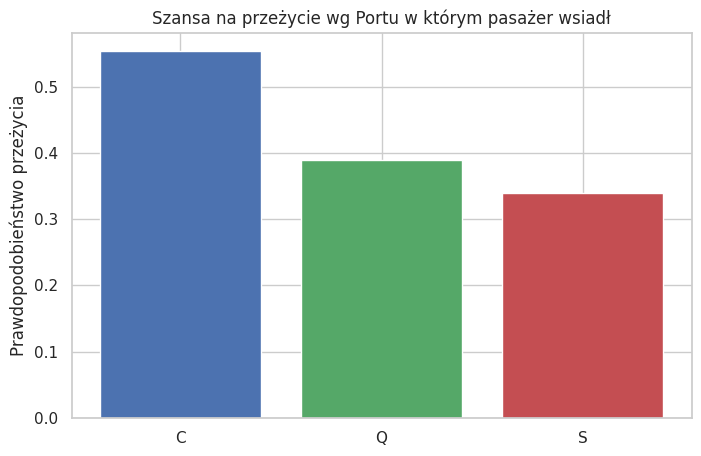

In [37]:
survival_rates = titanic_df.groupby('Embarked')['Survived'].mean()

plot_labels = ['C', 'Q', 'S']
plot_values = [
    survival_rates[1], # For 'C'
    survival_rates[2], # For 'Q'
    survival_rates[0]  # For 'S'
]

plt.figure(figsize=(8, 5))
plt.bar(plot_labels, plot_values, color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Szansa na przeżycie wg Portu w którym pasażer wsiadł')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.show()

Wykresy słupkowe porównujące szanse na przeżycie według liczby rodzeństwa/małżonków oraz według liczby rodziców/dzieci

/tmp/ipykernel_804/3572081183.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic_df, x='SibSp', y='Survived', ax=axes[0], palette='Blues_d')
/tmp/ipykernel_804/3572081183.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic_df, x='Parch', y='Survived', ax=axes[1], palette='Greens_d')


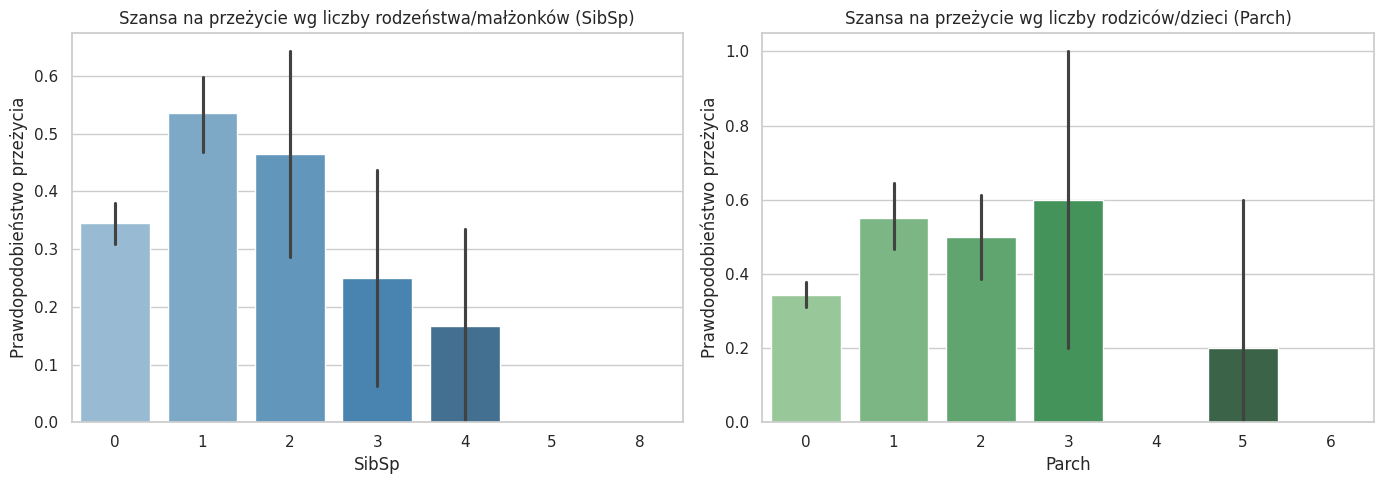

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

sns.barplot(data=titanic_df, x='SibSp', y='Survived', ax=axes[0], palette='Blues_d')
axes[0].set_title('Szansa na przeżycie wg liczby rodzeństwa/małżonków (SibSp)')
axes[0].set_ylabel('Prawdopodobieństwo przeżycia')

sns.barplot(data=titanic_df, x='Parch', y='Survived', ax=axes[1], palette='Greens_d')
axes[1].set_title('Szansa na przeżycie wg liczby rodziców/dzieci (Parch)')
axes[1].set_ylabel('Prawdopodobieństwo przeżycia')

plt.tight_layout()
plt.show()


Macierz korelacji (HeatMap) wszystkich cech

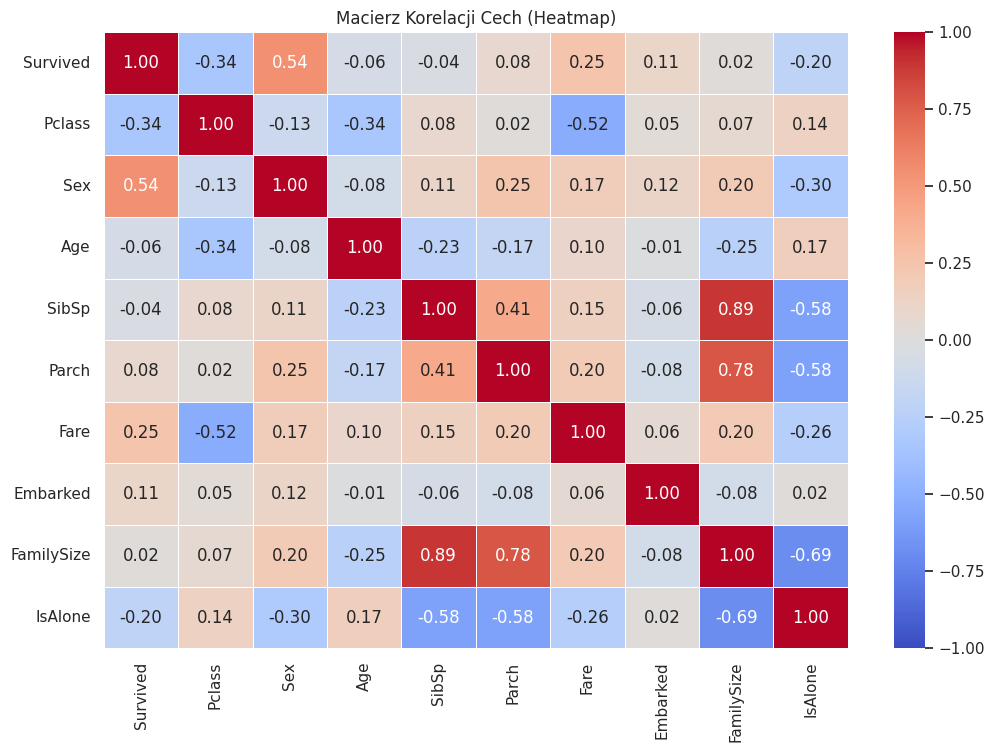

In [39]:
plt.figure(figsize=(12, 8))

correlation_matrix = titanic_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Macierz Korelacji Cech (Heatmap)')

plt.show()